Title: SEM_visualisation_plots.ipynb

Purpose: Make some plots

Author: Onno Nennecke on 22 January 2025 Modified: 17.03.2025

Input data: 


Output data:

   Some Plots - These files lie here: ~/Code/Figures/

Import packages

In [1]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt

import Functions.config as config
import Functions.wind_model_func as wind_model_func
import Functions.solar_model_func as solar_model_func
import Functions.demand as demand


# Wind Plots

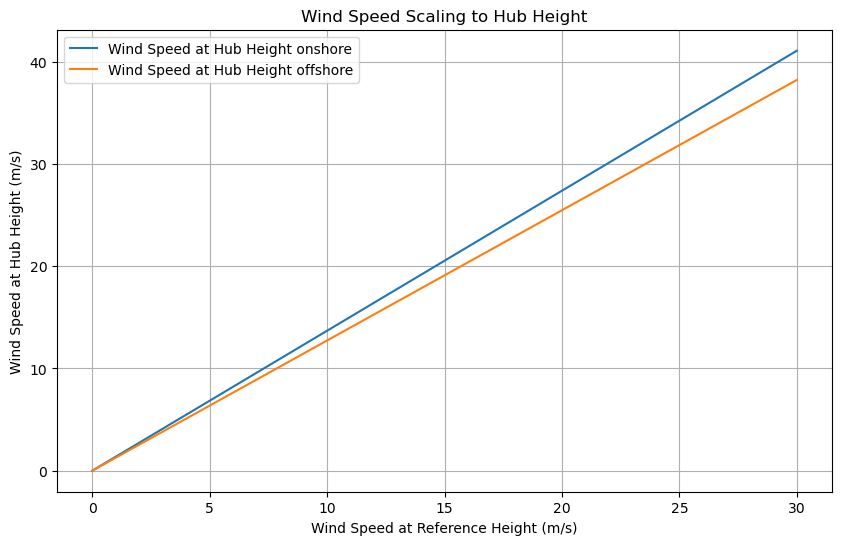

In [3]:
# Plot Wind profile power law
wind_speeds = np.linspace(0, 30, 100)

# Define hub height
hub_height_plt = 90

# Calculate wind speeds at hub height
wind_speeds_at_hub_height_on = wind_model_func._wind_scale(wind_speeds, hub_height_plt, config.a_onshore, config.height_ref)
wind_speeds_at_hub_height_off = wind_model_func._wind_scale(wind_speeds, hub_height_plt, config.a_offshore, config.height_ref)

# Plot the results
plt.figure(figsize=(10, 6))
plt.plot(wind_speeds, wind_speeds_at_hub_height_on, label='Wind Speed at Hub Height onshore')
plt.plot(wind_speeds, wind_speeds_at_hub_height_off, label='Wind Speed at Hub Height offshore')

plt.xlabel('Wind Speed at Reference Height (m/s)')
plt.ylabel('Wind Speed at Hub Height (m/s)')
plt.title('Wind Speed Scaling to Hub Height')
plt.legend()
plt.grid(True)
plt.show()

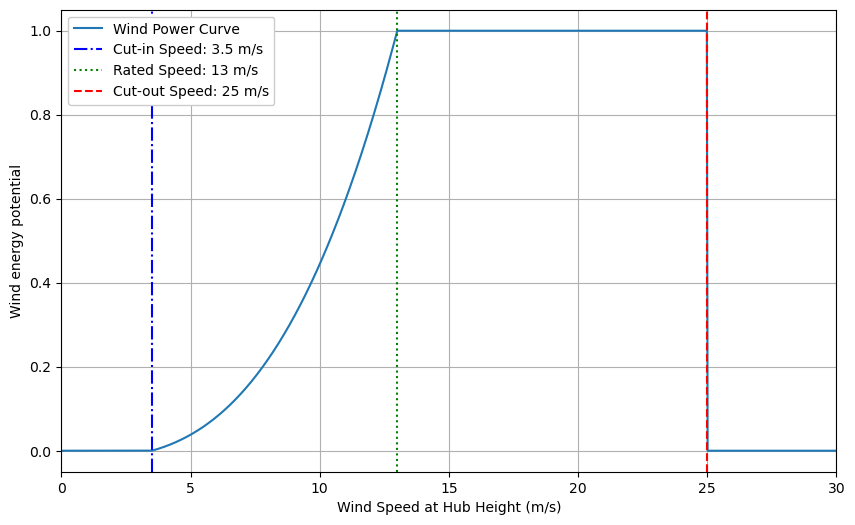

In [5]:
# Plot Wind profile power law
wind_speeds_plot = np.linspace(0, 30, 1000)

# Calculate wind speeds at hub height
wind_energy_prod_plot = wind_model_func._wind_power_curve(wind_speeds_plot, config.v_cutin0, config.v_rated0, config.v_cutout0)

# Plot the results
plt.figure(figsize=(10, 6))
plt.plot(wind_speeds_plot, wind_energy_prod_plot, label='Wind Power Curve')
plt.axvline(x=config.v_cutin0, color='b', linestyle='-.', label=f'Cut-in Speed: {config.v_cutin0} m/s')
plt.xlim(0, 30)
plt.axvline(x=config.v_rated0, color='g', linestyle=':', label=f'Rated Speed: {config.v_rated0} m/s')
plt.axvline(x=config.v_cutout0, color='r', linestyle='--', label=f'Cut-out Speed: {config.v_cutout0} m/s')
plt.xlabel('Wind Speed at Hub Height (m/s)')
plt.ylabel('Wind energy potential')
# plt.title('Wind power curve')
plt.legend(facecolor='white', framealpha=1)
plt.grid(True)

# Save plot
plt.savefig('/home/onennecke/Code/Figures/Wind_power_curve.png', dpi=300, bbox_inches='tight')

plt.show()

# Solar Plots

In [8]:
ESM = 'CESM2' 
run = 'r1i1p1f1'
# Temperature:
variable = 'tas' # 
nc = xr.open_mfdataset(f'/climca/data/CMIP6/CMIP/NCAR/{ESM}/historical/{run}/day/{variable}/gn/v20190308/tas_day_CESM2_historical_r1i1p1f1_gn_18500101-18591231.nc')
# select variable
tas = nc['tas'] 
tas
# filter winter
tas = tas[np.isin(tas.time.dt.month, [10,11,12,1,2,3]),:,:]
tas
# select region
tas = tas.sel(dict(lat=slice(45,60), lon=slice(5,15))) # At the moment roughly germany


/home/onennecke/.conda/envs/env_ma_on/lib/python3.12/site-packages/xarray/conventions.py:200: SerializationWarning: variable 'tas' has multiple fill values {np.float32(1e+20), np.float64(1e+20)} defined, decoding all values to NaN.
  var = coder.decode(var, name=name)


In [9]:
day_of_year = tas.time.dt.dayofyear
# day_of_year.values[0:200]

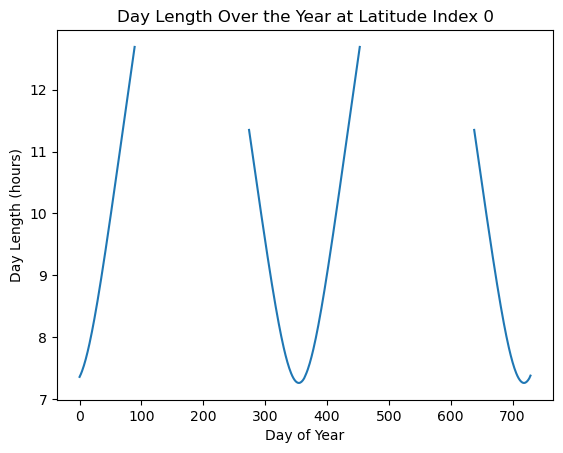

In [10]:
# Select a specific latitude (e.g., the first latitude)
latitude_index = 8
x = np.concatenate([np.arange(0, 90), np.full(184, np.nan), np.arange(274, 365+89), np.full(184, np.nan), np.arange(638, 730)])
plt.plot(x, solar_model_func._day_length(tas).isel(time=slice(0, 365*2), lat=latitude_index).values)
plt.xlabel('Day of Year')
plt.ylabel('Day Length (hours)')
plt.title('Day Length Over the Year at Latitude Index 0')
plt.show()

# Demand Plots

In [2]:
demand_fit_values = xr.open_dataset('/home/onennecke/EU-renewable-energy-modelling-framework/input_files/demand_fit/demand_fit_values.nc')

In [8]:
# Create array from -15:45
temperature_plt = np.arange(-20, 61, 0.5)
v_weekday = demand_fit_values.sel(country = 9, period = 'weekday')
v_weekend = demand_fit_values.sel(country = 9, period = 'weekend')
v_week = v_weekday * 5/7 + v_weekend * 2/7

In [9]:
for i in v_week.variables:
    print(i)
    print('Weekday:', v_weekday[i].values)
    print('Week:', v_week[i].values)
    print('Weekend:', v_weekend[i].values)

# print(v_weekday.values)
# print(v_weekend.values)

country
Weekday: 9
Week: 9
Weekend: 9
a
Weekday: 1598.998816165577
Week: 1520.0034971824782
Weekend: 1322.5151997247315
b
Weekday: -12.460044729419154
Week: -12.294560932468091
Weekend: -11.880851440090431
c
Weekday: 1322.613770352275
Week: 1263.0356952104485
Weekend: 1114.0905073558827
d
Weekday: 4.702090111035449
Week: 3.764188822956334
Weekend: 1.4194356027585453
e
Weekday: 0.3847279465417123
Week: 0.49294204457186364
Weekend: 0.763477289647242
f
Weekday: 17.047548688332604
Week: 16.19129018023932
Weekend: 14.050643910006116
heating_max
Weekday: 1775.7758241758243
Week: 1702.5083202511773
Weekend: 1519.3395604395603
cooling_max
Weekday: 1539.7065934065934
Week: 1472.8048665620095
Weekend: 1305.5505494505496
minT
Weekday: -12.498317128772253
Week: -12.193476972330895
Weekend: -11.4313765812275
maxT
Weekday: 28.40700348322221
Week: 28.225636414759805
Weekend: 27.772218743603805


In [10]:
demand_weekday = np.zeros(len(temperature_plt))
demand_weekend = np.zeros(len(temperature_plt))
demand_week = np.zeros(len(temperature_plt))

In [11]:
for i in range(len(temperature_plt)):
    demand_weekday[i] = demand.LSTRmodel(temperature_plt[i], v_weekday)
    if (demand_weekday[i] > v_weekday.heating_max) & (temperature_plt[i] < v_weekday.f):
        demand_weekday[i] = v_weekday.heating_max
    if (demand_weekday[i] > v_weekday.cooling_max) & (temperature_plt[i] > v_weekday.f):
        demand_weekday[i] = v_weekday.cooling_max

    demand_weekend[i] = demand.LSTRmodel(temperature_plt[i], v_weekend)
    if (demand_weekend[i] > v_weekend.heating_max) & (temperature_plt[i] < v_weekend.f):
        demand_weekend[i] = v_weekend.heating_max
    if (demand_weekend[i] > v_weekend.cooling_max) & (temperature_plt[i] > v_weekend.f):
        demand_weekend[i] = v_weekend.cooling_max
    
    demand_week[i] = demand.LSTRmodel(temperature_plt[i], v_week)
    if (demand_week[i] > v_week.heating_max) & (temperature_plt[i] < v_week.f):
        demand_week[i] = v_week.heating_max
    if (demand_week[i] > v_week.cooling_max) & (temperature_plt[i] > v_week.f):
        demand_week[i] = v_week.cooling_max
        


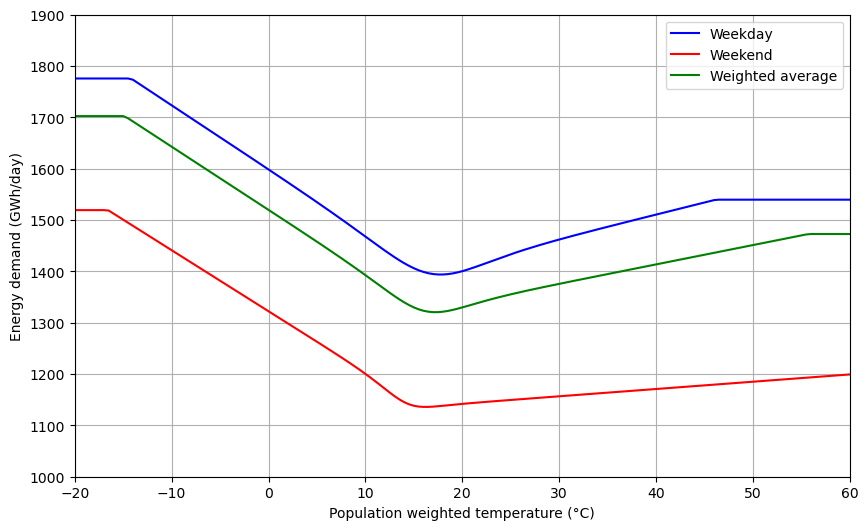

In [12]:
# Plot the demand against temperature
plt.figure(figsize=(10, 6))
plt.plot(temperature_plt, demand_weekday, linestyle='-', color='b')
plt.plot(temperature_plt, demand_weekend, linestyle='-', color='r')
plt.plot(temperature_plt, demand_week, linestyle='-', color='g')
# plt.title('Demand fit for Germany')
plt.xlabel('Population weighted temperature (°C)')
plt.ylabel('Energy demand (GWh/day)')
plt.grid(True)
plt.xlim([-20, 60])
plt.ylim([1000, 1900])

plt.legend(['Weekday', 'Weekend', 'Weighted average'], loc='upper right')

# save the plot
plt.savefig('/home/onennecke/Code/Figures/demand_fit_germany_draft.png', dpi=300, bbox_inches='tight')

plt.show()

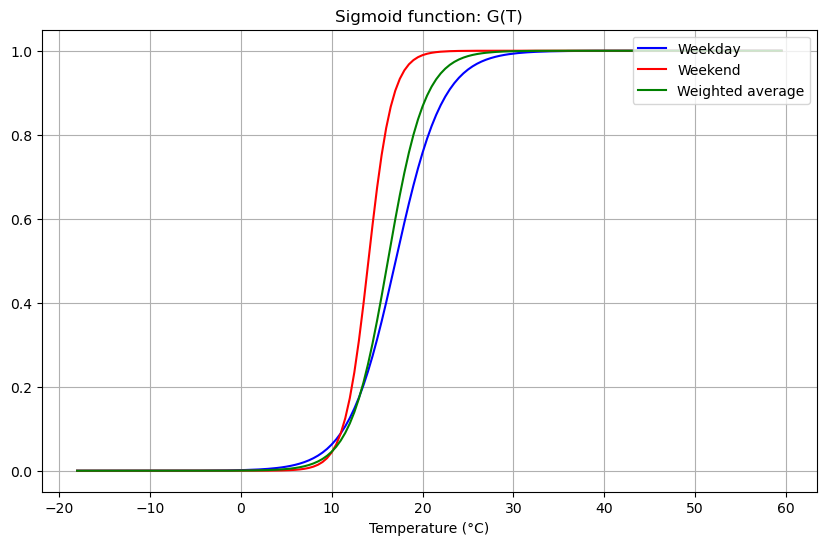

In [17]:
# G = 1 / (1 + np.exp(-v.e * (temperature_plt[i] - v.f)))

G_wday = np.zeros(len(temperature_plt))
G_wend = np.zeros(len(temperature_plt))
G_week = np.zeros(len(temperature_plt))


for i in range(len(temperature_plt)):
    G_wday[i] = 1 / (1 + np.exp(-v_weekday.e * (temperature_plt[i] - v_weekday.f)))
    G_wend[i] = 1 / (1 + np.exp(-v_weekend.e * (temperature_plt[i] - v_weekend.f)))
    G_week[i] = 1 / (1 + np.exp(-v_week.e * (temperature_plt[i] - v_week.f)))
    
    
# Plot the demand against temperature
plt.figure(figsize=(10, 6))
plt.plot(temperature_plt, G_wday, linestyle='-', color='b')
plt.plot(temperature_plt, G_wend, linestyle='-', color='r')
plt.plot(temperature_plt, G_week, linestyle='-', color='g')
plt.title('Sigmoid function: G(T)')
plt.xlabel('Temperature (°C)')
plt.legend(['Weekday', 'Weekend', 'Weighted average'], loc='upper right')

plt.grid(True)
plt.show()